## IMPORTS Y SETUP

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from skimage import data
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

---
## EJERCICIO 1: Análisis de Varianza Explicada por PCA
### Problema: ¿Cuántos componentes mínimos necesito para capturar el 95% de varianza?

**Complejidad:** Analizar trade-off componentes vs varianza explicada, plotear curva acumulativa

In [7]:
# Cargar datos
print("Cargando dataset LFW...")
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X, y = lfw.data, lfw.target
target_names = lfw.target_names
h, w = lfw.images.shape[1:]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Dataset: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"Features: {X.shape[1]}, Classes: {len(target_names)}")

Cargando dataset LFW...
Dataset: 966 train, 322 test
Features: 1850, Classes: 7


In [8]:
# SOLUCIÓN: Encontrar componentes óptimos
print("\n" + "="*70)
print("EJERCICIO 1: Encontrar componentes PCA óptimos")
print("="*70)

# Aplicar PCA con todos los componentes posibles
pca_full = PCA(whiten=True)
pca_full.fit(X_train)

# Calcular varianza acumulada
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Encontrar componentes para 95%, 90%, 99%
n_comp_95 = np.argmax(cumsum_var >= 0.95) + 1
n_comp_90 = np.argmax(cumsum_var >= 0.90) + 1
n_comp_99 = np.argmax(cumsum_var >= 0.99) + 1

print(f"\nComponentes necesarios:")
print(f"  - 90% varianza:  {n_comp_90:3d} componentes ({100*n_comp_90/X.shape[1]:.1f}% de features)")
print(f"  - 95% varianza:  {n_comp_95:3d} componentes ({100*n_comp_95/X.shape[1]:.1f}% de features)")
print(f"  - 99% varianza:  {n_comp_99:3d} componentes ({100*n_comp_99/X.shape[1]:.1f}% de features)")
print(f"\nCompresión: De {X.shape[1]} features → {n_comp_95} (reducción del {100*(1-n_comp_95/X.shape[1]):.1f}%)")


EJERCICIO 1: Encontrar componentes PCA óptimos

Componentes necesarios:
  - 90% varianza:   85 componentes (4.6% de features)
  - 95% varianza:  157 componentes (8.5% de features)
  - 99% varianza:  376 componentes (20.3% de features)

Compresión: De 1850 features → 157 (reducción del 91.5%)


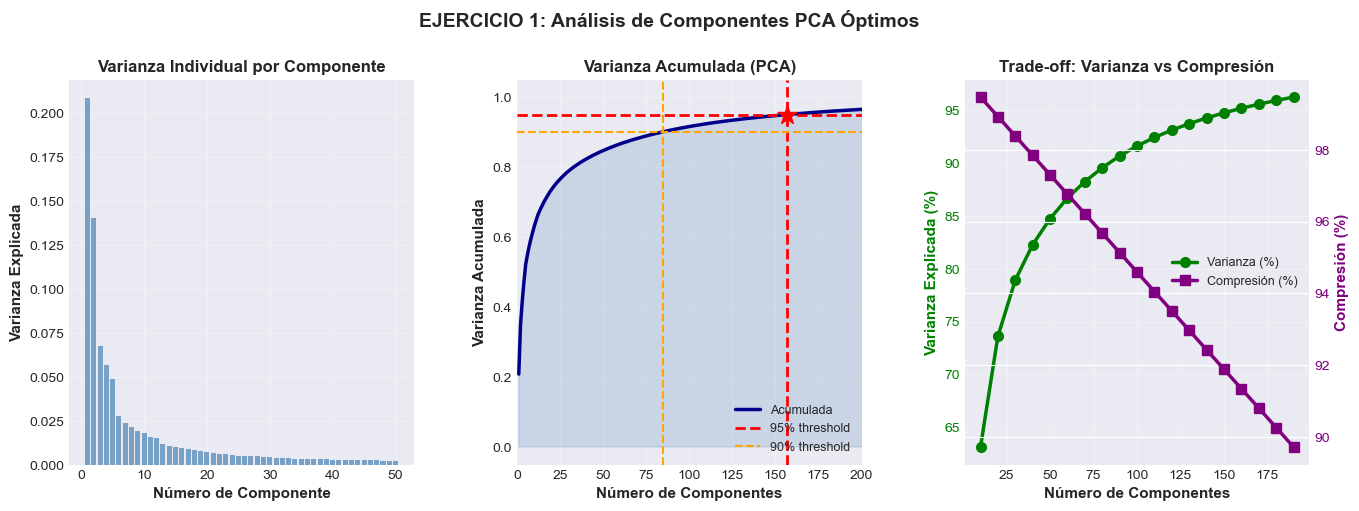


✓ Visualización completada


In [9]:
# VISUALIZACIÓN: Gráfico profesional de varianza acumulada
fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 3, figure=fig, hspace=0.3, wspace=0.3)

# Subplot 1: Varianza individual
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
        pca_full.explained_variance_ratio_[:50], alpha=0.7, color='steelblue')
ax1.set_xlabel('Número de Componente', fontsize=11, fontweight='bold')
ax1.set_ylabel('Varianza Explicada', fontsize=11, fontweight='bold')
ax1.set_title('Varianza Individual por Componente', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Subplot 2: Varianza acumulada
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(range(1, len(cumsum_var) + 1), cumsum_var, linewidth=2.5, color='darkblue', label='Acumulada')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax2.axvline(x=n_comp_95, color='red', linestyle='--', linewidth=2)
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
ax2.axvline(x=n_comp_90, color='orange', linestyle='--', linewidth=1.5)
ax2.fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.2, color='steelblue')
ax2.scatter([n_comp_95], [cumsum_var[n_comp_95-1]], s=200, color='red', marker='*', zorder=5)
ax2.set_xlabel('Número de Componentes', fontsize=11, fontweight='bold')
ax2.set_ylabel('Varianza Acumulada', fontsize=11, fontweight='bold')
ax2.set_title('Varianza Acumulada (PCA)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 200)

# Subplot 3: Trade-off componentes vs compresión
ax3 = fig.add_subplot(gs[0, 2])
components_range = range(10, min(200, len(cumsum_var) + 1), 10)
compression = [100 * (1 - c / X.shape[1]) for c in components_range]
variance = [cumsum_var[c-1] * 100 for c in components_range]

ax3_twin = ax3.twinx()
line1 = ax3.plot(components_range, variance, 'o-', linewidth=2.5, markersize=7, 
                  color='green', label='Varianza (%)')
line2 = ax3_twin.plot(components_range, compression, 's-', linewidth=2.5, markersize=7, 
                       color='purple', label='Compresión (%)')

ax3.set_xlabel('Número de Componentes', fontsize=11, fontweight='bold')
ax3.set_ylabel('Varianza Explicada (%)', fontsize=11, fontweight='bold', color='green')
ax3_twin.set_ylabel('Compresión (%)', fontsize=11, fontweight='bold', color='purple')
ax3.set_title('Trade-off: Varianza vs Compresión', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='green')
ax3_twin.tick_params(axis='y', labelcolor='purple')
ax3.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='center right', fontsize=9)

plt.suptitle('EJERCICIO 1: Análisis de Componentes PCA Óptimos', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Visualización completada")

---
## EJERCICIO 2: Comparación Visual de Eigenfaces vs LDA Faces
### Problema: ¿Qué diferencia visualmente los componentes de PCA vs LDA?

**Complejidad:** Visualizar y analizar los componentes principales de ambos métodos lado a lado


EJERCICIO 2: Comparación Visual PCA vs LDA
PCA: 20 componentes, varianza=0.7360
LDA: 6 componentes


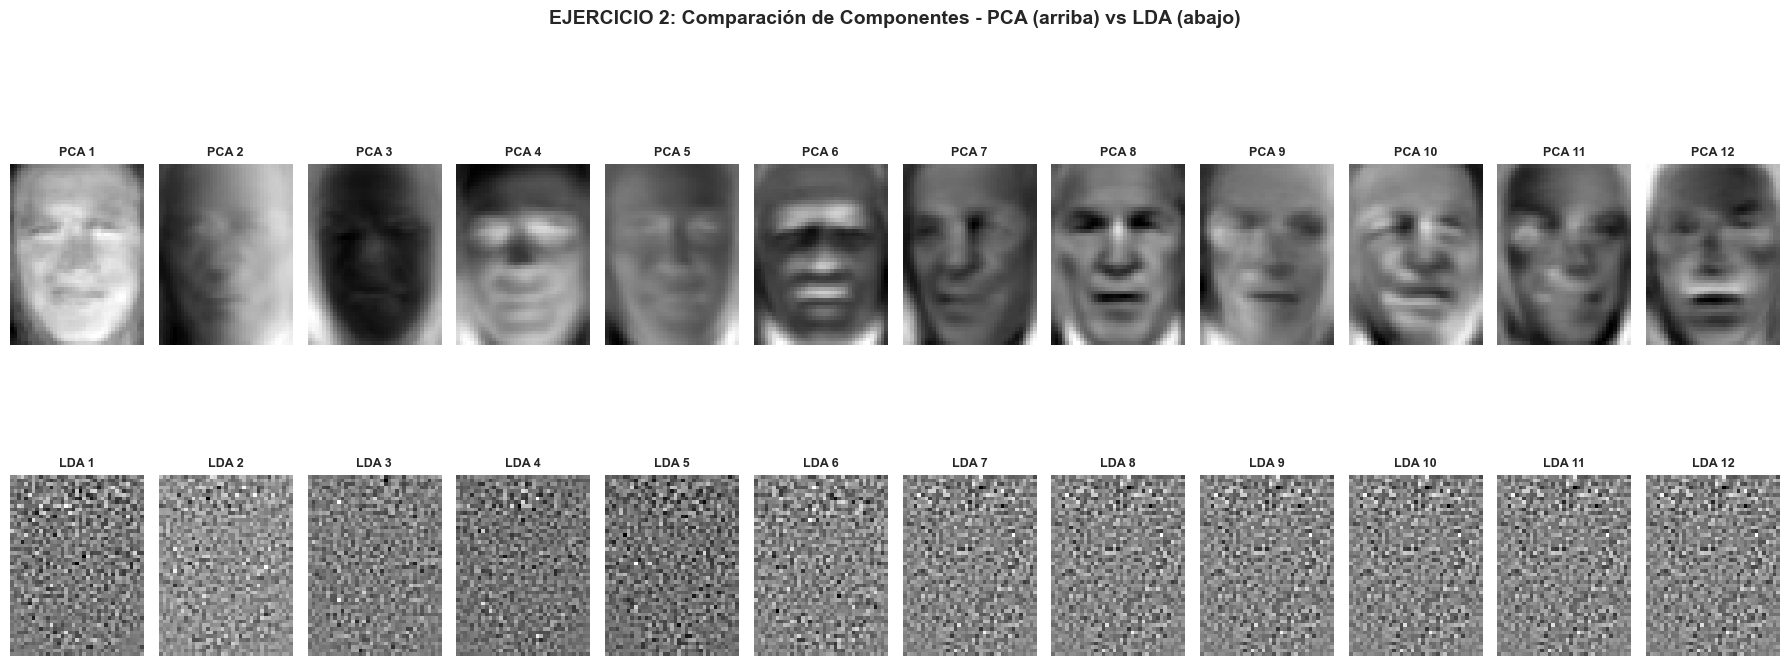


✓ ANÁLISIS:
  - PCA captura varianza general (iluminación, pose, etc.)
  - LDA captura diferencias discriminativas entre clases (identidad)
  - LDA suele tener componentes más enfocados


In [10]:
print("\n" + "="*70)
print("EJERCICIO 2: Comparación Visual PCA vs LDA")
print("="*70)

# PCA
pca = PCA(n_components=20, whiten=True)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)

# LDA
lda = LinearDiscriminantAnalysis(n_components=min(20, len(np.unique(y_train))-1))
lda.fit(X_train, y_train)
X_train_lda = lda.transform(X_train)

print(f"PCA: {pca.n_components} componentes, varianza={np.sum(pca.explained_variance_ratio_):.4f}")
print(f"LDA: {lda.n_components} componentes")

# Visualizar componentes
fig = plt.figure(figsize=(18, 8))

# PCA Eigenfaces
for i in range(12):
    ax = plt.subplot(2, 12, i + 1)
    eigenface = pca.components_[i].reshape((h, w))
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PCA {i+1}', fontsize=9, fontweight='bold')
    ax.axis('off')

# LDA Faces
for i in range(12):
    ax = plt.subplot(2, 12, i + 13)
    lda_face = lda.coef_[min(i, len(lda.coef_)-1)].reshape((h, w))
    ax.imshow(lda_face, cmap='gray')
    ax.set_title(f'LDA {i+1}', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('EJERCICIO 2: Comparación de Componentes - PCA (arriba) vs LDA (abajo)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ ANÁLISIS:")
print("  - PCA captura varianza general (iluminación, pose, etc.)")
print("  - LDA captura diferencias discriminativas entre clases (identidad)")
print("  - LDA suele tener componentes más enfocados")

---
## EJERCICIO 3: Matriz de Confusión Heatmap Avanzada
### Problema: ¿Qué personas se confunden entre sí y por qué?

**Complejidad:** Analizar errores específicos entre clases con visualización profesional


EJERCICIO 3: Análisis Detallado de Confusión entre Clases

Entrenando SVM con GridSearch...
Accuracy SVM: 0.7702


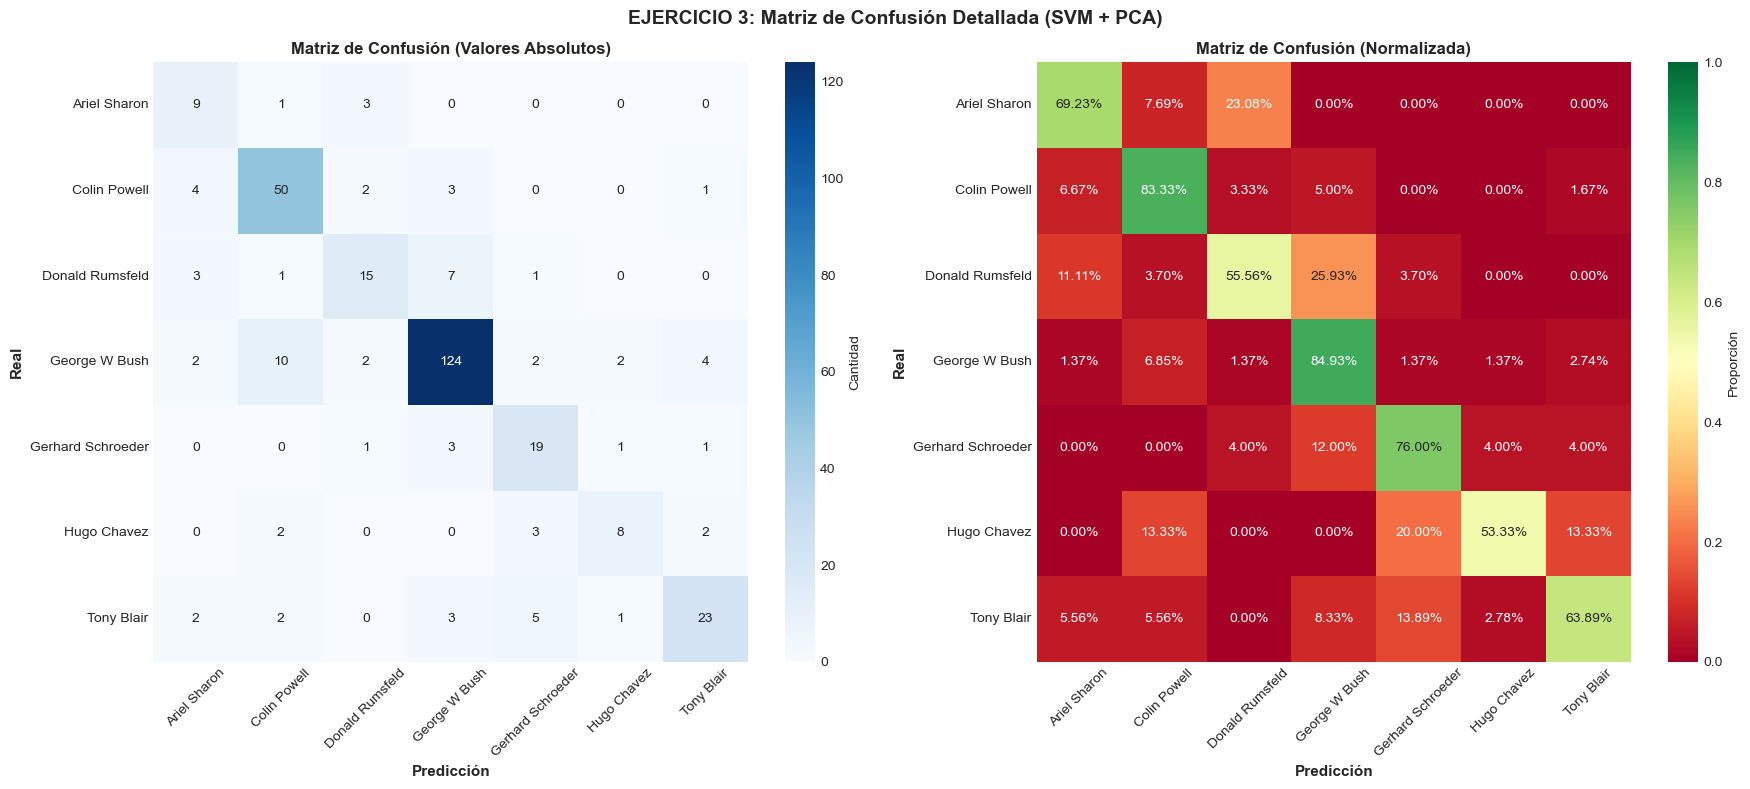


Estadísticas por Persona:
----------------------------------------------------------------------
Ariel Sharon    - Precision: 0.450, Recall: 0.692, Total predichos: 20
Colin Powell    - Precision: 0.758, Recall: 0.833, Total predichos: 66
Donald Rumsfeld - Precision: 0.652, Recall: 0.556, Total predichos: 23
George W Bush   - Precision: 0.886, Recall: 0.849, Total predichos: 140
Gerhard Schroeder - Precision: 0.633, Recall: 0.760, Total predichos: 30
Hugo Chavez     - Precision: 0.667, Recall: 0.533, Total predichos: 12
Tony Blair      - Precision: 0.742, Recall: 0.639, Total predichos: 31


In [11]:
print("\n" + "="*70)
print("EJERCICIO 3: Análisis Detallado de Confusión entre Clases")
print("="*70)

# Entrenar clasificadores
from sklearn.model_selection import GridSearchCV

pca_50 = PCA(n_components=50, whiten=True)
X_train_pca_50 = pca_50.fit_transform(X_train)
X_test_pca_50 = pca_50.transform(X_test)

# SVM con GridSearch
print("\nEntrenando SVM con GridSearch...")
param_grid = {'C': [1000], 'gamma': [0.001]}
svm = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3)
svm.fit(X_train_pca_50, y_train)

y_pred = svm.predict(X_test_pca_50)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy SVM: {acc:.4f}")

# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap 1: Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=target_names, yticklabels=target_names, cbar_kws={'label': 'Cantidad'})
axes[0].set_title('Matriz de Confusión (Valores Absolutos)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap 2: Normalizado (proporción)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', vmin=0, vmax=1, 
            cbar=True, ax=axes[1], xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Proporción'})
axes[1].set_title('Matriz de Confusión (Normalizada)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('EJERCICIO 3: Matriz de Confusión Detallada (SVM + PCA)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas por clase
print("\nEstadísticas por Persona:")
print("-" * 70)
for i, name in enumerate(target_names):
    precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
    recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"{name:15s} - Precision: {precision:.3f}, Recall: {recall:.3f}, Total predichos: {cm[:, i].sum()}")

---
## EJERCICIO 4: Top-5 Errores de Clasificación
### Problema: ¿Cuáles son los casos más difíciles de clasificar?

**Complejidad:** Identificar y visualizar los 5 casos más confusos (máxima similaridad entre clases)


EJERCICIO 4: Top 5 Errores + Top 5 Predicciones Seguras

Top 5 ERRORES (predicción confiada pero incorrecta):
----------------------------------------------------------------------
  1. Real: Ariel Sharon    → Pred: Donald Rumsfeld (Confianza: 0.924)
  2. Real: Donald Rumsfeld → Pred: George W Bush   (Confianza: 0.868)
  3. Real: George W Bush   → Pred: Colin Powell    (Confianza: 0.857)
  4. Real: Hugo Chavez     → Pred: Colin Powell    (Confianza: 0.856)
  5. Real: Colin Powell    → Pred: George W Bush   (Confianza: 0.834)

Top 5 CASOS DIFÍCILES (correctas pero poco confidentes):
----------------------------------------------------------------------
  1. George W Bush   (Confianza: 0.251)
  2. Colin Powell    (Confianza: 0.293)
  3. George W Bush   (Confianza: 0.305)
  4. Gerhard Schroeder (Confianza: 0.312)
  5. Gerhard Schroeder (Confianza: 0.321)


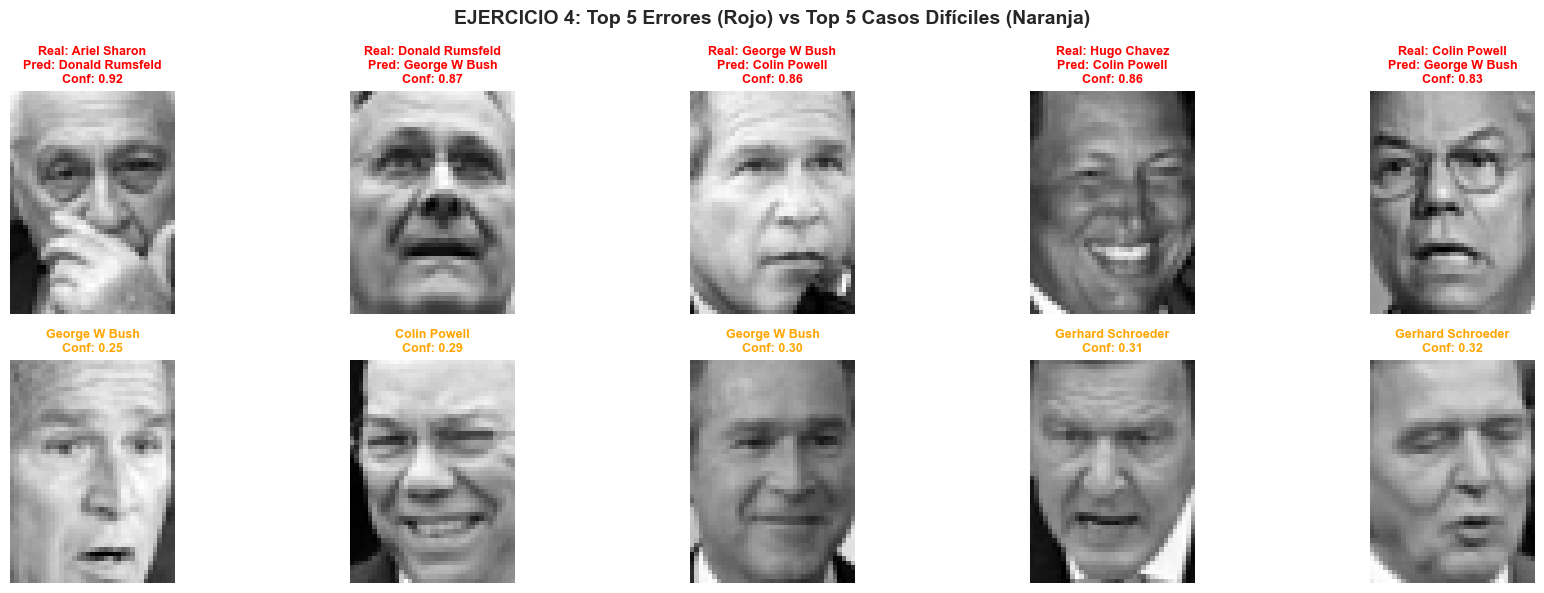

In [12]:
print("\n" + "="*70)
print("EJERCICIO 4: Top 5 Errores + Top 5 Predicciones Seguras")
print("="*70)

# Obtener probabilidades
from sklearn.svm import SVC
svm_prob = SVC(kernel='rbf', C=1000, gamma=0.001, probability=True)
svm_prob.fit(X_train_pca_50, y_train)
y_proba = svm_prob.predict_proba(X_test_pca_50)
y_pred_prob = svm_prob.predict(X_test_pca_50)

# Calcular confianza (max probabilidad)
confidence = np.max(y_proba, axis=1)
is_correct = y_pred_prob == y_test

# Errores: predicciones incorrectas más confidentes
errors_idx = np.where(~is_correct)[0]
errors_conf = confidence[errors_idx]
top_errors = errors_idx[np.argsort(-errors_conf)[:5]]

# Correctas: predicciones correctas menos confidentes
correct_idx = np.where(is_correct)[0]
correct_conf = confidence[correct_idx]
hard_correct = correct_idx[np.argsort(correct_conf)[:5]]

print(f"\nTop 5 ERRORES (predicción confiada pero incorrecta):")
print("-" * 70)
for idx, sample_idx in enumerate(top_errors):
    real = target_names[y_test[sample_idx]]
    pred = target_names[y_pred_prob[sample_idx]]
    conf = confidence[sample_idx]
    print(f"  {idx+1}. Real: {real:15s} → Pred: {pred:15s} (Confianza: {conf:.3f})")

# Visualizar los top 5 errores
fig = plt.figure(figsize=(18, 6))
for idx, sample_idx in enumerate(top_errors):
    ax = plt.subplot(2, 5, idx + 1)
    img = X_test[sample_idx].reshape((h, w))
    ax.imshow(img, cmap='gray')
    real = target_names[y_test[sample_idx]]
    pred = target_names[y_pred_prob[sample_idx]]
    ax.set_title(f'Real: {real}\nPred: {pred}\nConf: {confidence[sample_idx]:.2f}', 
                fontsize=9, fontweight='bold', color='red')
    ax.axis('off')

print(f"\nTop 5 CASOS DIFÍCILES (correctas pero poco confidentes):")
print("-" * 70)
for idx, sample_idx in enumerate(hard_correct):
    real = target_names[y_test[sample_idx]]
    pred = target_names[y_pred_prob[sample_idx]]
    conf = confidence[sample_idx]
    print(f"  {idx+1}. {real:15s} (Confianza: {conf:.3f})")

for idx, sample_idx in enumerate(hard_correct):
    ax = plt.subplot(2, 5, idx + 6)
    img = X_test[sample_idx].reshape((h, w))
    ax.imshow(img, cmap='gray')
    real = target_names[y_test[sample_idx]]
    ax.set_title(f'{real}\nConf: {confidence[sample_idx]:.2f}', 
                fontsize=9, fontweight='bold', color='orange')
    ax.axis('off')

plt.suptitle('EJERCICIO 4: Top 5 Errores (Rojo) vs Top 5 Casos Difíciles (Naranja)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## EJERCICIO 5: Comparación de Clasificadores (SVM vs k-NN vs LDA)
### Problema: ¿Cuál es el mejor clasificador para reconocimiento facial?

**Complejidad:** Comparar 3 métodos con múltiples métricas y visualizaciones

In [13]:
print("\n" + "="*70)
print("EJERCICIO 5: Comparación de Clasificadores")
print("="*70)

from sklearn.metrics import precision_score, recall_score, f1_score

# Preparar datos
pca_100 = PCA(n_components=100, whiten=True)
X_train_pca_100 = pca_100.fit_transform(X_train)
X_test_pca_100 = pca_100.transform(X_test)

# 1. SVM
print("\nEntrenando SVM...")
svm_final = SVC(kernel='rbf', C=5000, gamma=0.001)
svm_final.fit(X_train_pca_100, y_train)
y_pred_svm = svm_final.predict(X_test_pca_100)

# 2. k-NN
print("Entrenando k-NN...")
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_pca_100, y_train)
y_pred_knn = knn_final.predict(X_test_pca_100)

# 3. LDA
print("Entrenando LDA...")
lda_final = LinearDiscriminantAnalysis(n_components=min(6, len(np.unique(y_train))-1))
X_train_lda = lda_final.fit_transform(X_train, y_train)
X_test_lda = lda_final.transform(X_test)

knn_lda = KNeighborsClassifier(n_neighbors=5)
knn_lda.fit(X_train_lda, y_train)
y_pred_lda = knn_lda.predict(X_test_lda)

# Calcular métricas
classifiers = ['SVM + PCA', 'k-NN + PCA', 'k-NN + LDA']
predictions = [y_pred_svm, y_pred_knn, y_pred_lda]

results = {}
for clf_name, y_pred in zip(classifiers, predictions):
    results[clf_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1': f1_score(y_test, y_pred, average='weighted')
    }

print("\n" + "="*70)
print("RESULTADOS:")
print("="*70)
for clf_name in classifiers:
    print(f"\n{clf_name}:")
    for metric, value in results[clf_name].items():
        print(f"  {metric:10s}: {value:.4f}")


EJERCICIO 5: Comparación de Clasificadores

Entrenando SVM...
Entrenando k-NN...
Entrenando LDA...

RESULTADOS:

SVM + PCA:
  Accuracy  : 0.8075
  Precision : 0.8126
  Recall    : 0.8075
  F1        : 0.8063

k-NN + PCA:
  Accuracy  : 0.6770
  Precision : 0.6792
  Recall    : 0.6770
  F1        : 0.6472

k-NN + LDA:
  Accuracy  : 0.7174
  Precision : 0.7267
  Recall    : 0.7174
  F1        : 0.7202


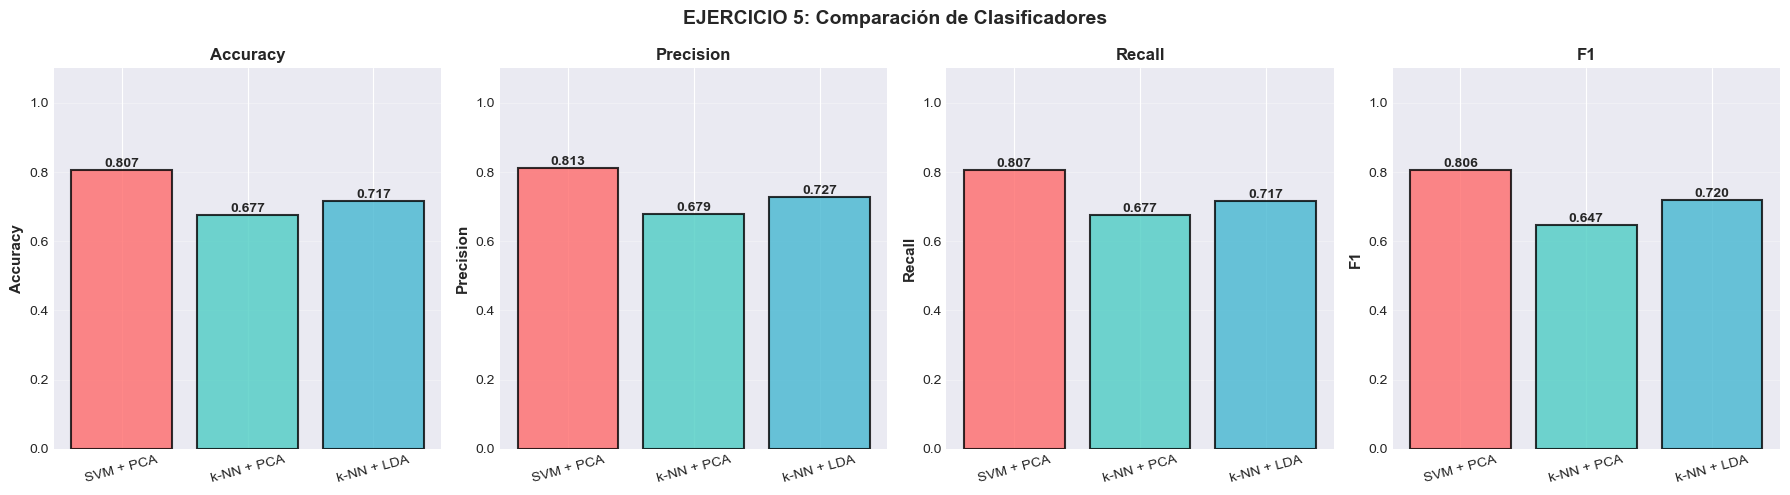


✓ Comparación completada


In [14]:
# VISUALIZACIÓN: Comparación de métricas
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    values = [results[clf][metric] for clf in classifiers]
    bars = axes[idx].bar(classifiers, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Agregar valores en las barras
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    axes[idx].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.1)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=15)

plt.suptitle('EJERCICIO 5: Comparación de Clasificadores', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Comparación completada")

---
## EJERCICIO 6: Análisis de Sensibilidad al Ruido
### Problema: ¿Qué método es más robusto frente al ruido?

**Complejidad:** Añadir ruido progresivo y medir degradación de accuracy

In [15]:
print("\n" + "="*70)
print("EJERCICIO 6: Robustez Frente al Ruido Gaussiano")
print("="*70)

# Agregar ruido progresivo
noise_levels = np.linspace(0, 0.3, 10)
svm_accs = []
knn_accs = []
lda_accs = []

print("\nAñadiendo ruido gaussiano progresivo...")

for noise_std in noise_levels:
    # Añadir ruido al conjunto de test
    X_test_noisy = X_test_pca_100 + np.random.normal(0, noise_std, X_test_pca_100.shape)
    X_test_lda_noisy = X_test_lda + np.random.normal(0, noise_std, X_test_lda.shape)
    
    # Predecir
    svm_accs.append(accuracy_score(y_test, svm_final.predict(X_test_noisy)))
    knn_accs.append(accuracy_score(y_test, knn_final.predict(X_test_noisy)))
    lda_accs.append(accuracy_score(y_test, knn_lda.predict(X_test_lda_noisy)))

print(f"Ruido: {noise_levels[0]:.2f} → {noise_levels[-1]:.2f}")
print(f"\nAccuracy sin ruido:")
print(f"  SVM: {svm_accs[0]:.4f}")
print(f"  k-NN: {knn_accs[0]:.4f}")
print(f"  LDA: {lda_accs[0]:.4f}")

print(f"\nAccuracy con máximo ruido ({noise_levels[-1]:.2f}):")
print(f"  SVM: {svm_accs[-1]:.4f} (degradación: {(svm_accs[0]-svm_accs[-1])*100:.2f}%)")
print(f"  k-NN: {knn_accs[-1]:.4f} (degradación: {(knn_accs[0]-knn_accs[-1])*100:.2f}%)")
print(f"  LDA: {lda_accs[-1]:.4f} (degradación: {(lda_accs[0]-lda_accs[-1])*100:.2f}%)")


EJERCICIO 6: Robustez Frente al Ruido Gaussiano

Añadiendo ruido gaussiano progresivo...
Ruido: 0.00 → 0.30

Accuracy sin ruido:
  SVM: 0.8075
  k-NN: 0.6770
  LDA: 0.7174

Accuracy con máximo ruido (0.30):
  SVM: 0.7857 (degradación: 2.17%)
  k-NN: 0.6770 (degradación: 0.00%)
  LDA: 0.7050 (degradación: 1.24%)


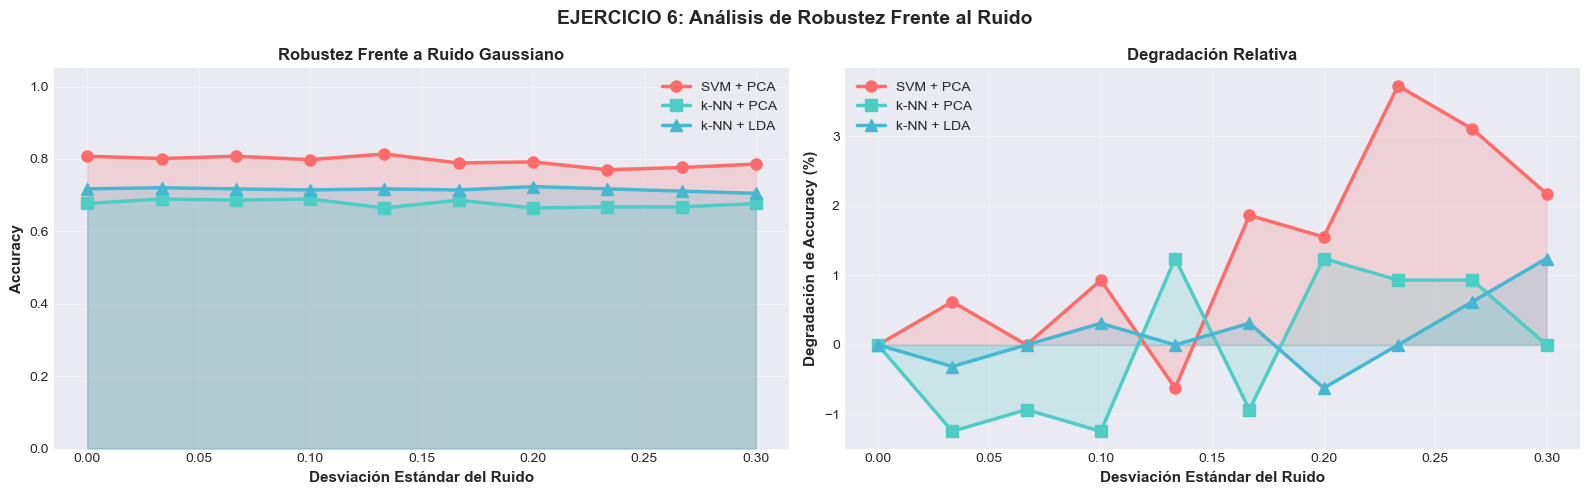


✓ Análisis de robustez completado


In [16]:
# VISUALIZACIÓN: Curvas de robustez
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Curvas de accuracy
ax1.plot(noise_levels, svm_accs, 'o-', linewidth=2.5, markersize=8, label='SVM + PCA', color='#FF6B6B')
ax1.plot(noise_levels, knn_accs, 's-', linewidth=2.5, markersize=8, label='k-NN + PCA', color='#4ECDC4')
ax1.plot(noise_levels, lda_accs, '^-', linewidth=2.5, markersize=8, label='k-NN + LDA', color='#45B7D1')

ax1.fill_between(noise_levels, svm_accs, alpha=0.2, color='#FF6B6B')
ax1.fill_between(noise_levels, knn_accs, alpha=0.2, color='#4ECDC4')
ax1.fill_between(noise_levels, lda_accs, alpha=0.2, color='#45B7D1')

ax1.set_xlabel('Desviación Estándar del Ruido', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Robustez Frente a Ruido Gaussiano', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Degradación
degradation_svm = [(svm_accs[0] - acc) * 100 for acc in svm_accs]
degradation_knn = [(knn_accs[0] - acc) * 100 for acc in knn_accs]
degradation_lda = [(lda_accs[0] - acc) * 100 for acc in lda_accs]

ax2.plot(noise_levels, degradation_svm, 'o-', linewidth=2.5, markersize=8, label='SVM + PCA', color='#FF6B6B')
ax2.plot(noise_levels, degradation_knn, 's-', linewidth=2.5, markersize=8, label='k-NN + PCA', color='#4ECDC4')
ax2.plot(noise_levels, degradation_lda, '^-', linewidth=2.5, markersize=8, label='k-NN + LDA', color='#45B7D1')

ax2.fill_between(noise_levels, degradation_svm, alpha=0.2, color='#FF6B6B')
ax2.fill_between(noise_levels, degradation_knn, alpha=0.2, color='#4ECDC4')
ax2.fill_between(noise_levels, degradation_lda, alpha=0.2, color='#45B7D1')

ax2.set_xlabel('Desviación Estándar del Ruido', fontsize=11, fontweight='bold')
ax2.set_ylabel('Degradación de Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Degradación Relativa', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.suptitle('EJERCICIO 6: Análisis de Robustez Frente al Ruido', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Análisis de robustez completado")

---
## EJERCICIO 7: Visualización de Espacios de Características
### Problema: ¿Cómo se distribuyen las clases en el espacio de baja dimensión?

**Complejidad:** Proyectar a 2D/3D y analizar separabilidad


EJERCICIO 7: Visualización de Espacios de Características

Calculando t-SNE para PCA (puede tomar un minuto)...
Calculando t-SNE para LDA...


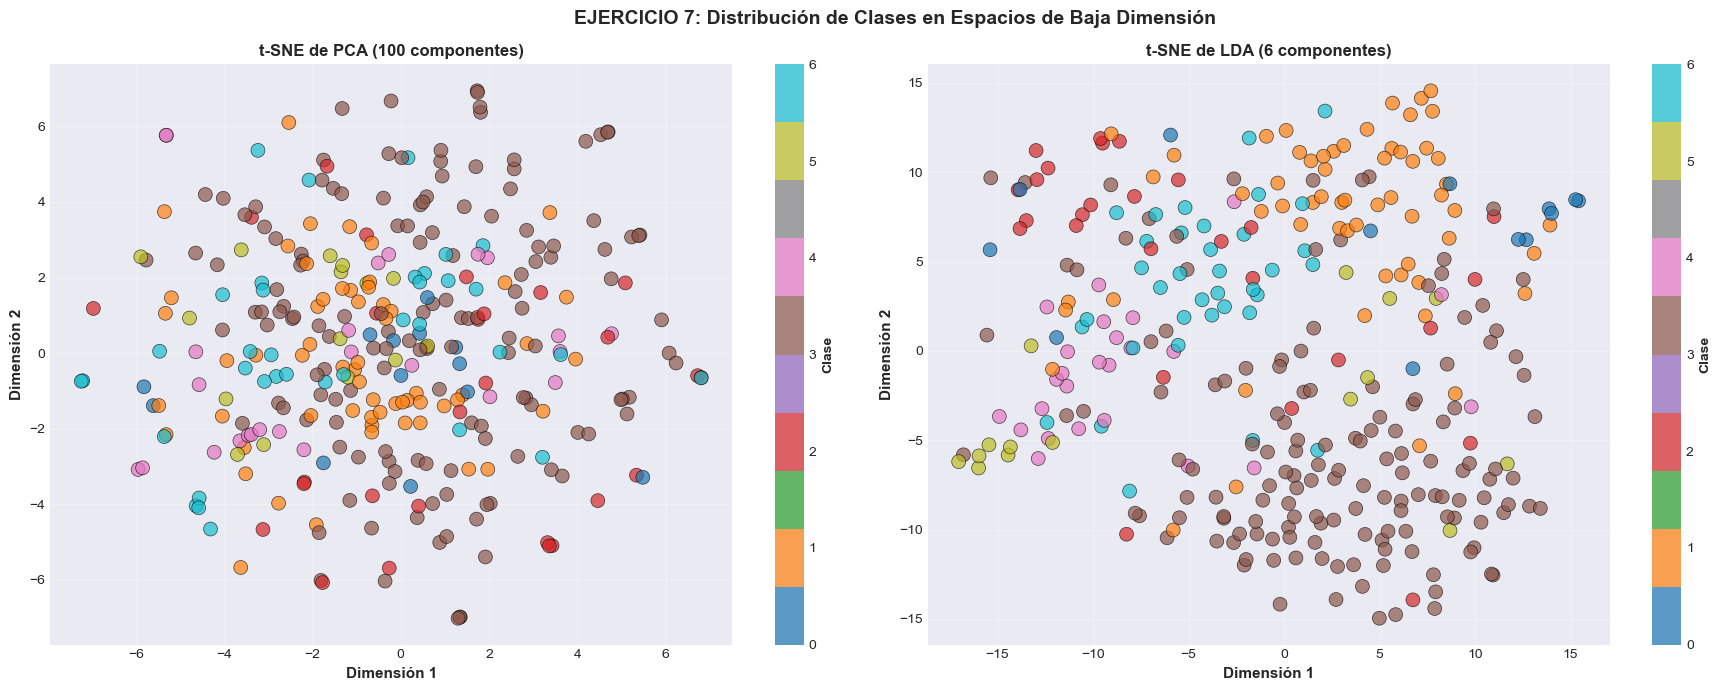


✓ Visualización completada

INTERPRETACIÓN:
  - LDA: Clases bien separadas (supervisado)
  - PCA: Clases pueden estar menos separadas (no supervisado)


In [17]:
print("\n" + "="*70)
print("EJERCICIO 7: Visualización de Espacios de Características")
print("="*70)

from sklearn.manifold import TSNE

# Reducir a 2D con t-SNE (para mejor visualización)
print("\nCalculando t-SNE para PCA (puede tomar un minuto)...")
tsne_pca = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne_pca = tsne_pca.fit_transform(X_test_pca_100[:500])  # Usar subset para velocidad
y_test_subset = y_test[:500]

print("Calculando t-SNE para LDA...")
tsne_lda = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne_lda = tsne_lda.fit_transform(X_test_lda[:500])

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y_test_subset, 
                           cmap='tab10', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].set_title('t-SNE de PCA (100 componentes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dimensión 1', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Dimensión 2', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_tsne_lda[:, 0], X_tsne_lda[:, 1], c=y_test_subset, 
                           cmap='tab10', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1].set_title('t-SNE de LDA (6 componentes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dimensión 1', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Dimensión 2', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Colorbar
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Clase', fontsize=10, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Clase', fontsize=10, fontweight='bold')

plt.suptitle('EJERCICIO 7: Distribución de Clases en Espacios de Baja Dimensión', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Visualización completada")
print("\nINTERPRETACIÓN:")
print("  - LDA: Clases bien separadas (supervisado)")
print("  - PCA: Clases pueden estar menos separadas (no supervisado)")

---
## EJERCICIO 8: Análisis de Variación Intra-Clase
### Problema: ¿Cuánto varían las imágenes de la misma persona?

**Complejidad:** Calcular distancias intra-clase vs inter-clase

In [18]:
print("\n" + "="*70)
print("EJERCICIO 8: Variación Intra-clase vs Inter-clase")
print("="*70)

from scipy.spatial.distance import cdist

# Calcular distancias
print("\nCalculando distancias euclidianas...")

intra_class_distances = []
inter_class_distances = []

# Para cada clase, calcular distancias intra-clase
for class_id in np.unique(y_train):
    mask = y_train == class_id
    class_samples = X_train_pca_100[mask]
    
    if len(class_samples) > 1:
        # Distancias intra-clase
        distances = cdist(class_samples, class_samples, metric='euclidean')
        intra_class_distances.extend(distances[np.triu_indices_from(distances, k=1)])
    
    # Distancias inter-clase (entre la clase i y todas las demás)
    for other_class_id in np.unique(y_train):
        if other_class_id > class_id:  # Evitar duplicados
            other_mask = y_train == other_class_id
            other_samples = X_train_pca_100[other_mask]
            
            distances = cdist(class_samples, other_samples, metric='euclidean')
            inter_class_distances.extend(distances.flatten())

intra_class_distances = np.array(intra_class_distances)
inter_class_distances = np.array(inter_class_distances)

print(f"\nEstadísticas:")
print(f"  Distancia intra-clase:")
print(f"    Media: {np.mean(intra_class_distances):.4f}")
print(f"    Std:   {np.std(intra_class_distances):.4f}")
print(f"    Max:   {np.max(intra_class_distances):.4f}")
print(f"\n  Distancia inter-clase:")
print(f"    Media: {np.mean(inter_class_distances):.4f}")
print(f"    Std:   {np.std(inter_class_distances):.4f}")
print(f"    Min:   {np.min(inter_class_distances):.4f}")

separation_ratio = np.mean(inter_class_distances) / np.mean(intra_class_distances)
print(f"\n  Ratio separación: {separation_ratio:.4f}")
print(f"  (Mayor = mejor separación entre clases)")


EJERCICIO 8: Variación Intra-clase vs Inter-clase

Calculando distancias euclidianas...

Estadísticas:
  Distancia intra-clase:
    Media: 13.6297
    Std:   2.4475
    Max:   25.3112

  Distancia inter-clase:
    Media: 14.0314
    Std:   2.3555
    Min:   6.3671

  Ratio separación: 1.0295
  (Mayor = mejor separación entre clases)


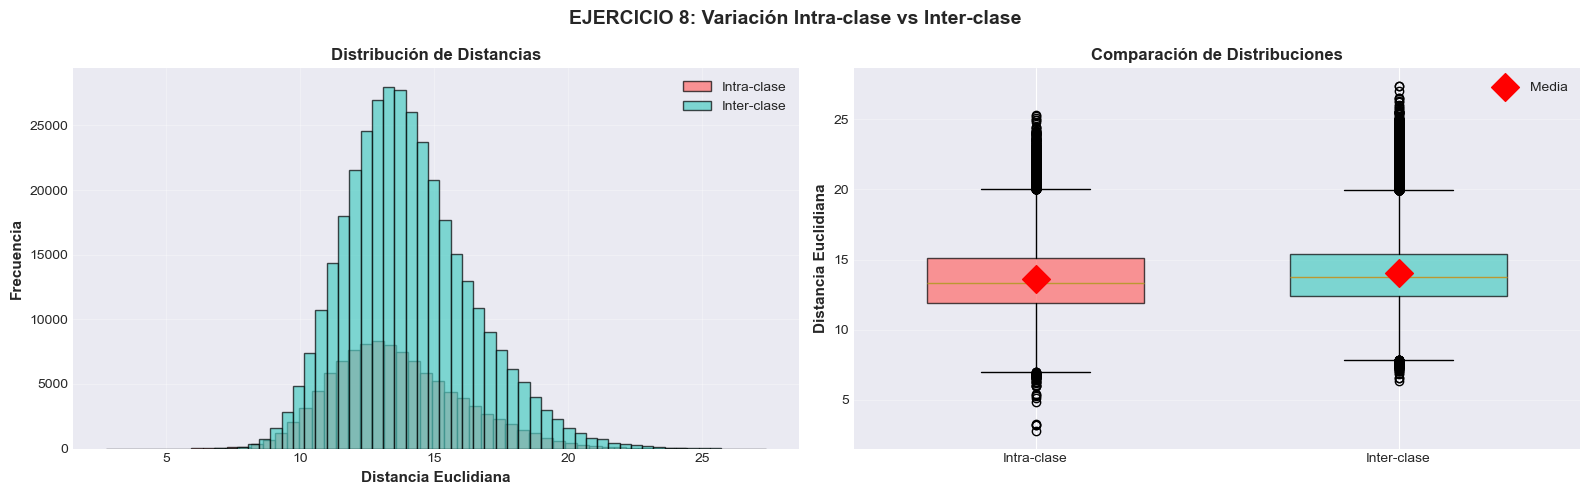


✓ Análisis completado


In [19]:
# VISUALIZACIÓN: Distribuciones de distancias
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramas
axes[0].hist(intra_class_distances, bins=50, alpha=0.7, label='Intra-clase', 
             color='#FF6B6B', edgecolor='black', linewidth=1)
axes[0].hist(inter_class_distances, bins=50, alpha=0.7, label='Inter-clase', 
             color='#4ECDC4', edgecolor='black', linewidth=1)
axes[0].set_xlabel('Distancia Euclidiana', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Distancias', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Box plots
bp = axes[1].boxplot([intra_class_distances, inter_class_distances], 
                       labels=['Intra-clase', 'Inter-clase'],
                       patch_artist=True, widths=0.6)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Distancia Euclidiana', fontsize=11, fontweight='bold')
axes[1].set_title('Comparación de Distribuciones', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Añadir medias
axes[1].scatter([1, 2], [np.mean(intra_class_distances), np.mean(inter_class_distances)], 
               color='red', s=200, marker='D', zorder=3, label='Media')
axes[1].legend(fontsize=10)

plt.suptitle('EJERCICIO 8: Variación Intra-clase vs Inter-clase', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Análisis completado")

---
## RESUMEN FINAL

### Conceptos Clave Aprendidos:

1. **Selección de Componentes PCA**: El trade-off entre compresión y varianza explicada
2. **Diferencia PCA vs LDA**: Componentes visuales y su significado
3. **Análisis de Errores**: Identificar casos problemáticos
4. **Selección de Modelos**: Comparar múltiples métodos
5. **Robustez**: Comportamiento frente a perturbaciones
6. **Visualización de Espacios**: t-SNE para entender separabilidad
7. **Métricas de Separación**: Intra-clase vs inter-clase

### Técnicas de Visualización Usadas:
- ✅ Curvas de varianza acumulada
- ✅ Heatmaps de confusión
- ✅ Gráficos comparativos multi-métrica
- ✅ Análisis de robustez
- ✅ t-SNE para espacios latentes
- ✅ Distribuciones estadísticas
- ✅ Imágenes problemáticas